<a href="https://colab.research.google.com/github/specM7/DSGP_Group_33_Brain_Tumor_Predictor/blob/glioblastoma-Vidu-2425444/tumour_mapping1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import zipfile

zip_path = "/content/drive/MyDrive/archive.zip"
extract_path = "/content/extracted"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Done extracting!")


Done extracting!


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Saved class_names.json


Epoch 1/10 | Train Loss: 0.7208 | Train Acc: 0.7398 | Val Loss: 0.4206   | Val Acc: 0.8369
  --> Best model saved (Val Acc: 0.8369)
Epoch 2/10 | Train Loss: 0.3491 | Train Acc: 0.8675 | Val Loss: 0.3124   | Val Acc: 0.8925
  --> Best model saved (Val Acc: 0.8925)
Epoch 3/10 | Train Loss: 0.2551 | Train Acc: 0.9075 | Val Loss: 0.2328   | Val Acc: 0.9313
  --> Best model saved (Val Acc: 0.9313)
Epoch 4/10 | Train Loss: 0.2249 | Train Acc: 0.9163 | Val Loss: 0.2199   | Val Acc: 0.9425
  --> Best model saved (Val Acc: 0.9425)
Epoch 5/10 | Train Loss: 0.1938 | Train Acc: 0.9314 | Val Loss: 0.2631   | Val Acc: 0.9306
Epoch 6/10 | Train Loss: 0.1922 | Train Acc: 0.9280 | Val Loss: 0.2101   | Val Acc: 0.9469
  --> Best model saved (Val Acc: 0.9469)
Epoch 7/10 | Train Loss: 0.1730 | Train Acc: 0.9352 | Val Loss: 0.2080   | Val Acc: 0.9537
  --> Best model saved (Val Acc: 0.9537)
Epoch 8/10 | Train Loss: 0.1695 | Train Acc: 0.9400 | Val Loss: 0.2309   | Val Acc: 0.9469
Epoch 9/10 | Train Loss: 0

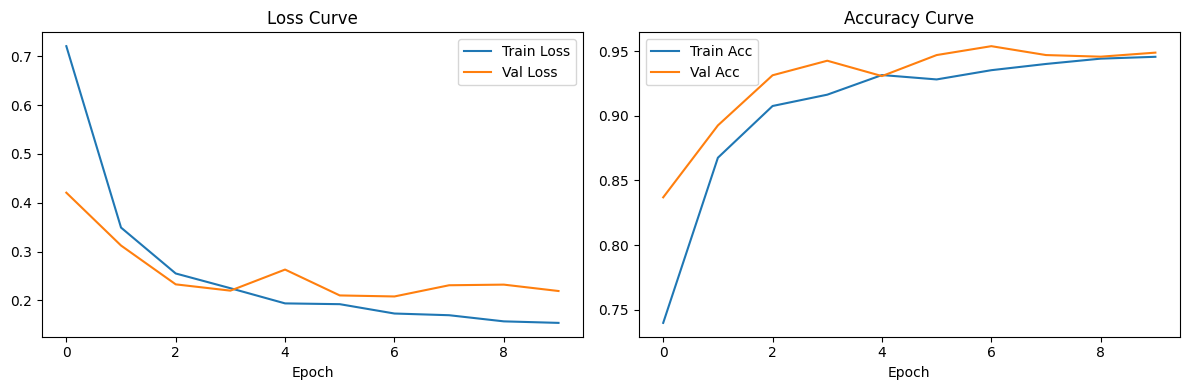

Saved training_curves.png


In [2]:
import os
import json
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import timm
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform

# ========================
# CONFIG
# ========================
root = "/content/extracted/archive"
train_dir = os.path.join(root, "Training")
test_dir  = os.path.join(root, "Testing")

img_size   = 380
batch_size = 16
epochs     = 10
device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ========================
# SEED
# ========================
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# ========================
# BRAIN CROPPING
# ========================
def crop_brain(img: Image.Image) -> Image.Image:
    img_np = np.array(img)
    gray   = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) == 0:
        return img

    cnt = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(cnt)
    cropped = img_np[y:y+h, x:x+w]
    return Image.fromarray(cropped)

# ========================
# TRANSFORMS
# ========================
# FIX 1: Delete temp model after config extraction to free memory
temp_model = timm.create_model("efficientnet_b4", pretrained=True)
config     = resolve_data_config({}, model=temp_model)
del temp_model

# FIX 2: is_training=True enables augmentation for training
train_transform = create_transform(**config, is_training=True)
test_transform  = create_transform(**config, is_training=False)

# ========================
# CROP WRAPPER
# ========================
# FIX 3: Actually apply crop_brain before the timm transforms
class CropAndTransform:
    def __init__(self, transform):
        self.transform = transform

    def __call__(self, img: Image.Image):
        img = crop_brain(img)
        return self.transform(img)

train_transform_with_crop = CropAndTransform(train_transform)
test_transform_with_crop  = CropAndTransform(test_transform)

# ========================
# DATASETS
# ========================
train_set = datasets.ImageFolder(train_dir, transform=train_transform_with_crop)
test_set  = datasets.ImageFolder(test_dir,  transform=test_transform_with_crop)

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

class_names = train_set.classes
num_classes = len(class_names)

print("Classes:", class_names)

# FIX 4: Save class names so Grad-CAM script can load them independently
with open("class_names.json", "w") as f:
    json.dump(class_names, f)
print("Saved class_names.json")

# ========================
# MODEL (EfficientNetB4)
# ========================
model = timm.create_model("efficientnet_b4", pretrained=True)
model.classifier = nn.Linear(model.classifier.in_features, num_classes)
model = model.to(device)

# Freeze all, then unfreeze last 3 blocks + classifier
for param in model.parameters():
    param.requires_grad = False

for param in model.blocks[-3:].parameters():
    param.requires_grad = True

for param in model.classifier.parameters():
    param.requires_grad = True

# ========================
# LOSS, OPTIMIZER & SCHEDULER
# ========================
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

# FIX 5: Add cosine LR scheduler for better convergence
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

# ========================
# TRAINING LOOP
# ========================
def train_one_epoch():
    model.train()
    total_loss = 0
    correct    = 0
    total      = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        preds       = outputs.argmax(1)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)

    return total_loss / total, correct / total

# FIX 6: Track val loss in evaluate()
@torch.no_grad()
def evaluate():
    model.eval()
    total_loss = 0
    correct    = 0
    total      = 0

    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs      = model(imgs)
        loss         = criterion(outputs, labels)

        total_loss += loss.item() * imgs.size(0)
        preds       = outputs.argmax(1)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)

    return total_loss / total, correct / total

# ========================
# TRAIN MODEL
# ========================
best_val_acc = 0.0
train_losses, train_accs = [], []
val_losses,   val_accs   = [], []

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch()
    val_loss,   val_acc   = evaluate()
    scheduler.step()

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}   | Val Acc: {val_acc:.4f}"
    )

    # FIX 7: Save best model by val accuracy, not just last epoch
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "efficientnet_b4_tumor_best.pth")
        print(f"  --> Best model saved (Val Acc: {best_val_acc:.4f})")

# Also save final epoch model
torch.save(model.state_dict(), "efficientnet_b4_tumor_last.pth")
print(f"\nTraining complete. Best Val Acc: {best_val_acc:.4f}")

# ========================
# PLOT TRAINING CURVES
# ========================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label="Train Loss")
axes[0].plot(val_losses,   label="Val Loss")
axes[0].set_title("Loss Curve")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(train_accs, label="Train Acc")
axes[1].plot(val_accs,   label="Val Acc")
axes[1].set_title("Accuracy Curve")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()
print("Saved training_curves.png")

In [3]:
pip install grad-cam


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 82.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=296d399d776102981dd8669c593c006058738a9b5133ba7c5f138a37239d90a0
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


Running Grad-CAM++ on: /content/extracted/archive/Testing/glioma/Te-gl_23.jpg


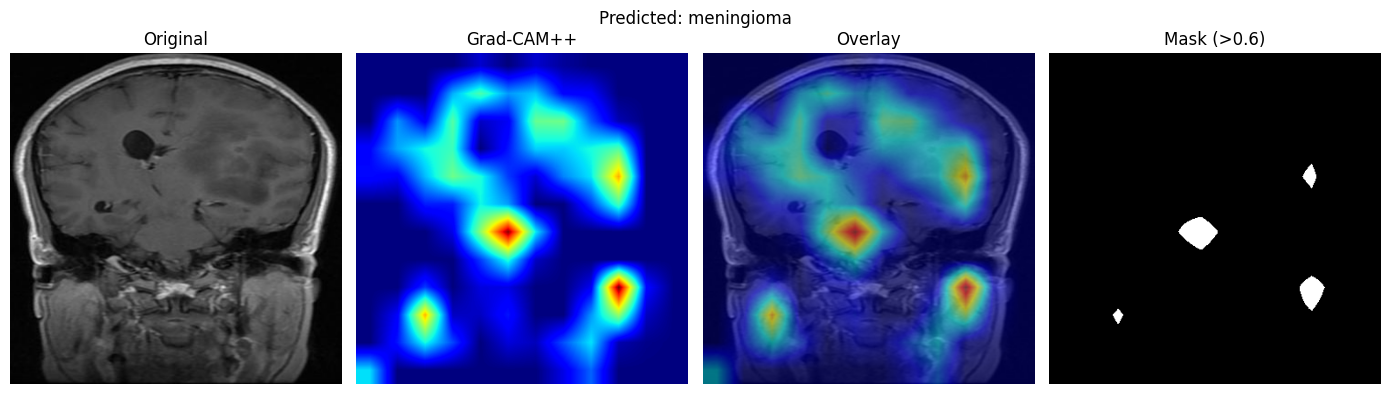

In [29]:
import os
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
from torchvision import transforms
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import timm

# ========================
# CONFIG
# ========================
img_size = 380
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ========================
# IMAGE CROPPING
# ========================
def crop_brain(img: Image.Image) -> Image.Image:
    img_np = np.array(img)
    gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) == 0:          # ✅ Fixed: was un-indented
        return img                  # ✅ Fixed: was un-indented

    cnt = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(cnt)
    cropped = img_np[y:y+h, x:x+w]
    return Image.fromarray(cropped) # ✅ Fixed: was un-indented

# ========================
# TRANSFORM
# ========================
test_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])  # ✅ Fixed: alignment
])

# ========================
# MODEL SETUP (EfficientNetB4 - timm)
# ========================
model = timm.create_model("efficientnet_b4", pretrained=True)
num_classes = len(class_names)
model.classifier = nn.Linear(model.classifier.in_features, num_classes)
model.load_state_dict(torch.load("efficientnet_b4_tumor_best.pth", map_location=device))
model = model.to(device)
model.eval()

target_layers = [model.blocks[-1]]
cam = GradCAMPlusPlus(
    model=model,
    target_layers=target_layers
)

def apply_gradcam_pp(img_path, mask_threshold=0.6):
    # Load + crop
    pil = Image.open(img_path).convert("RGB")
    pil = crop_brain(pil)

    # Resize ONCE
    pil_resized = pil.resize((img_size, img_size))

    # Prepare model input
    x = test_transform(pil_resized).unsqueeze(0).to(device)

    # Prediction
    with torch.no_grad():           # ✅ Fixed: was un-indented
        outputs = model(x)
        class_idx = outputs.argmax(1).item()

    # Grad-CAM++
    grayscale_cam = cam(
        input_tensor=x,
        targets=[ClassifierOutputTarget(class_idx)]
    )[0]                            # ✅ Fixed: closing bracket alignment

    # Ensure CAM matches image size
    grayscale_cam = cv2.resize(grayscale_cam, (img_size, img_size))

    # Convert image for visualization
    original_np = np.array(pil_resized).astype(np.float32) / 255.0

    # Overlay
    visualization = show_cam_on_image(original_np, grayscale_cam, use_rgb=True)

    # Binary mask
    mask = (grayscale_cam > mask_threshold).astype(np.uint8)

    # ========================
    # PLOT RESULTS
    # ========================
    plt.figure(figsize=(14, 4))

    plt.subplot(1, 4, 1)
    plt.title("Original")
    plt.imshow(original_np)
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.title("Grad-CAM++")
    plt.imshow(grayscale_cam, cmap="jet")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.title("Overlay")
    plt.imshow(visualization)
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.title(f"Mask (>{mask_threshold})")
    plt.imshow(mask, cmap="gray")
    plt.axis("off")

    plt.suptitle(f"Predicted: {class_names[class_idx]}")
    plt.tight_layout()
    plt.show()

# ========================
# TEST ON RANDOM IMAGE
# ========================
some_class = random.choice(class_names)
folder = os.path.join(test_dir, some_class)
example_img = os.path.join(folder, random.choice(os.listdir(folder)))
print("Running Grad-CAM++ on:", example_img)
apply_gradcam_pp(example_img, mask_threshold=0.6)